In [1]:
import pandas as pd
import numpy as np
import skimpy as sk
import mlflow
import mlflow.sklearn
from pyngrok import ngrok
import hmmlearn
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna
import scipy.stats as ss
from statsmodels.tsa.api import *
from matplotlib import cm
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from arch import arch_model


from sklearn.preprocessing import *
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor

import joblib
from warnings import filterwarnings; filterwarnings("ignore")

/home/voltsy/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
train = pd.read_csv("Data/diamonds_train.csv")
test = pd.read_csv("Data/diamonds_test.csv")
train

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.21,Premium,J,VS2,62.4,58.0,4268,6.83,6.79,4.25
1,0.32,Very Good,H,VS2,63.0,57.0,505,4.35,4.38,2.75
2,0.71,Fair,G,VS1,65.5,55.0,2686,5.62,5.53,3.65
3,0.41,Good,D,SI1,63.8,56.0,738,4.68,4.72,3.00
4,1.02,Ideal,G,SI1,60.5,59.0,4882,6.55,6.51,3.95
...,...,...,...,...,...,...,...,...,...,...
40450,1.34,Ideal,G,VS1,62.7,57.0,10070,7.10,7.04,4.43
40451,2.02,Good,F,SI2,57.1,60.0,12615,8.31,8.25,4.73
40452,1.01,Ideal,H,SI1,62.7,56.0,5457,6.37,6.42,4.01
40453,0.33,Ideal,J,VS1,61.9,54.3,456,4.45,4.47,2.76


In [3]:
test

,id,carat,cut,color,clarity,depth,table,x,y,z
0,0,0.79,Very Good,F,SI1,62.7,60.0,5.82,5.89,3.67
1,1,1.20,Ideal,J,VS1,61.0,57.0,6.81,6.89,4.18
2,2,1.57,Premium,H,SI1,62.2,61.0,7.38,7.32,4.57
3,3,0.90,Very Good,F,SI1,63.8,54.0,6.09,6.13,3.90
4,4,0.50,Very Good,F,VS1,62.9,58.0,5.05,5.09,3.19
...,...,...,...,...,...,...,...,...,...,...
13480,13480,0.57,Ideal,E,SI1,61.9,56.0,5.35,5.32,3.30
13481,13481,0.71,Ideal,I,VS2,62.2,55.0,5.71,5.73,3.56
13482,13482,0.70,Ideal,F,VS1,61.6,55.0,5.75,5.71,3.53
13483,13483,0.70,Very Good,F,SI2,58.8,57.0,5.85,5.89,3.45


In [4]:
sk.skim(train)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 40455  │ │ float64     │ 6     │                                                          │
│ │ Number of columns │ 10     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃ column    ┃ NA   ┃ NA %   ┃ mean      ┃ sd        ┃ p0    ┃ p25    ┃ p50    ┃ p75     ┃ p100    ┃ hist     ┃  │
│ ┡━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ carat     │    0 │      0 │    0.7977 │    0.4755 │   0.2 │    0.4 │    0.7 │    1.04 │     4.5 │   █▄▁    │  │
│ │ depth     │    0 │      0 │     61.75 │     1.432 │    43 │     61 │   61.8 │    62.5 │      79 │     ▂█   │  │
│ │ table     │    0 │      0 │     57.45 │     2.234 │    43 │     56 │     57 │      59 │      95 │    █▁    │  │
│ │ price     │    0 │      0 │      3928 │      3992 │   326 │    945 │   2397 │    5331 │   18820 │   █▃▁▁   │  │
│ │ x         │    0 │      0 │     5.729 │     1.124 │     0 │   4.71 │   5.69 │    6.54 │   10.23 │    ▆█▃   │  │
│ │ y         │    0 │      0 │     5.733 │     1.147 │     0 │   4.72 │   5.71 │    6.54 │    58.9 │    █     │  │
│ │ z         │    0 │      0 │     3.537 │    0.6971 │     0 │   2.91 │   3.52 │   4.035 │    8.06 │    ▁█▃   │  │
│ └───────────┴──────┴────────┴───────────┴───────────┴───────┴────────┴────────┴─────────┴─────────┴──────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃         ┃    ┃      ┃          ┃           ┃      ┃           ┃               ┃ words per    ┃             ┃  │
│ ┃ column  ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min  ┃ max       ┃ chars per row ┃ row          ┃ total words ┃  │
│ ┡━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ cut     │  0 │    0 │ Fair     │ Very Good │ Fair │ Very Good │          6.29 │          1.2 │       49550 │  │
│ │ color   │  0 │    0 │ J        │ J         │ D    │ J         │             1 │            1 │       40455 │  │
│ │ clarity │  0 │    0 │ IF       │ VVS1      │ I1   │ VVS2      │          3.12 │            1 │       40455 │  │
│ └─────────┴────┴──────┴──────────┴───────────┴──────┴───────────┴───────────────┴──────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [5]:
train.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [6]:
#train["price"].plot(kind="line")

## EDA

In [7]:
os.makedirs("Visualizations", exist_ok=True)

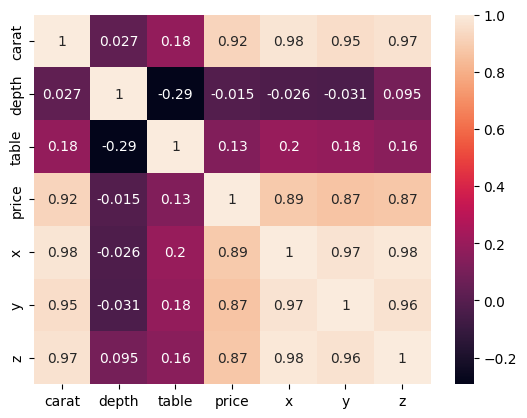

In [8]:
numerical_cols = train[[col for col in train.columns if col != "clarity" and col != "color" and col != "cut"]]

corr = numerical_cols.corr()
sns.heatmap(corr, annot=True)
plt.savefig("Visualizations/Correlation.png")
plt.show()

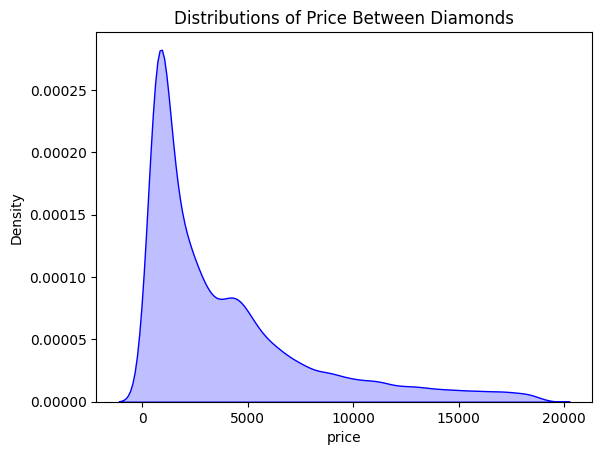

In [9]:
sns.kdeplot(data=train, x=train["price"], fill=True, color='blue')
plt.title("Distributions of Price Between Diamonds")
plt.savefig("Visualizations/Distributions of Price Between Diamonds.png")

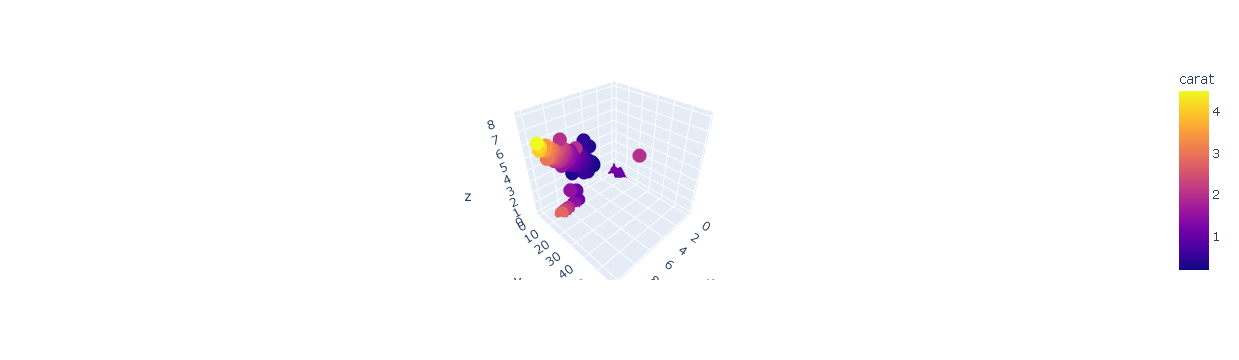

In [10]:
#Visualization of the structure of diamonds
X = train["x"]
Y = train["y"]
Z = train["z"]

fig = px.scatter_3d(train, x=X, y=Y, z=Z, color='carat')
fig.show()

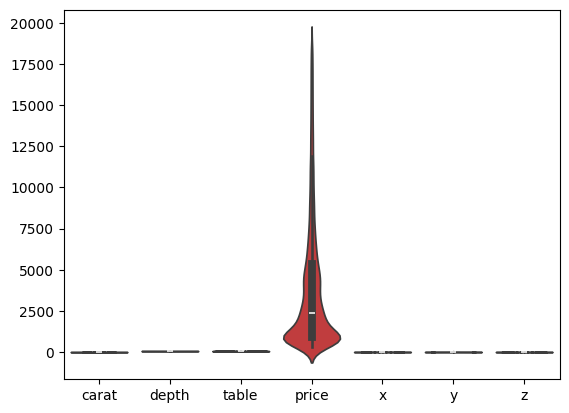

In [11]:
sns.violinplot(train)
plt.savefig("Visualizations/outliers.png")

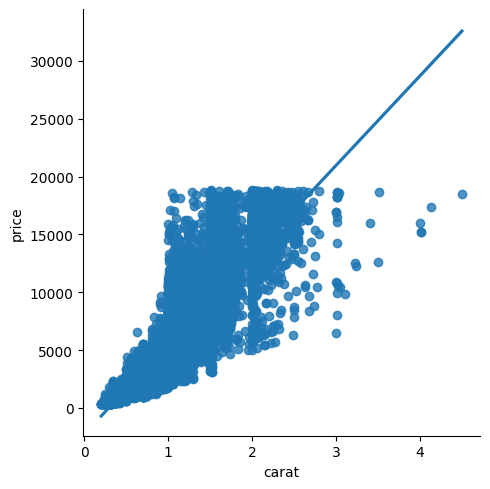

In [12]:
sns.lmplot(data=train, x="carat", y="price")
plt.savefig("Visualizations/regression_plots.png")

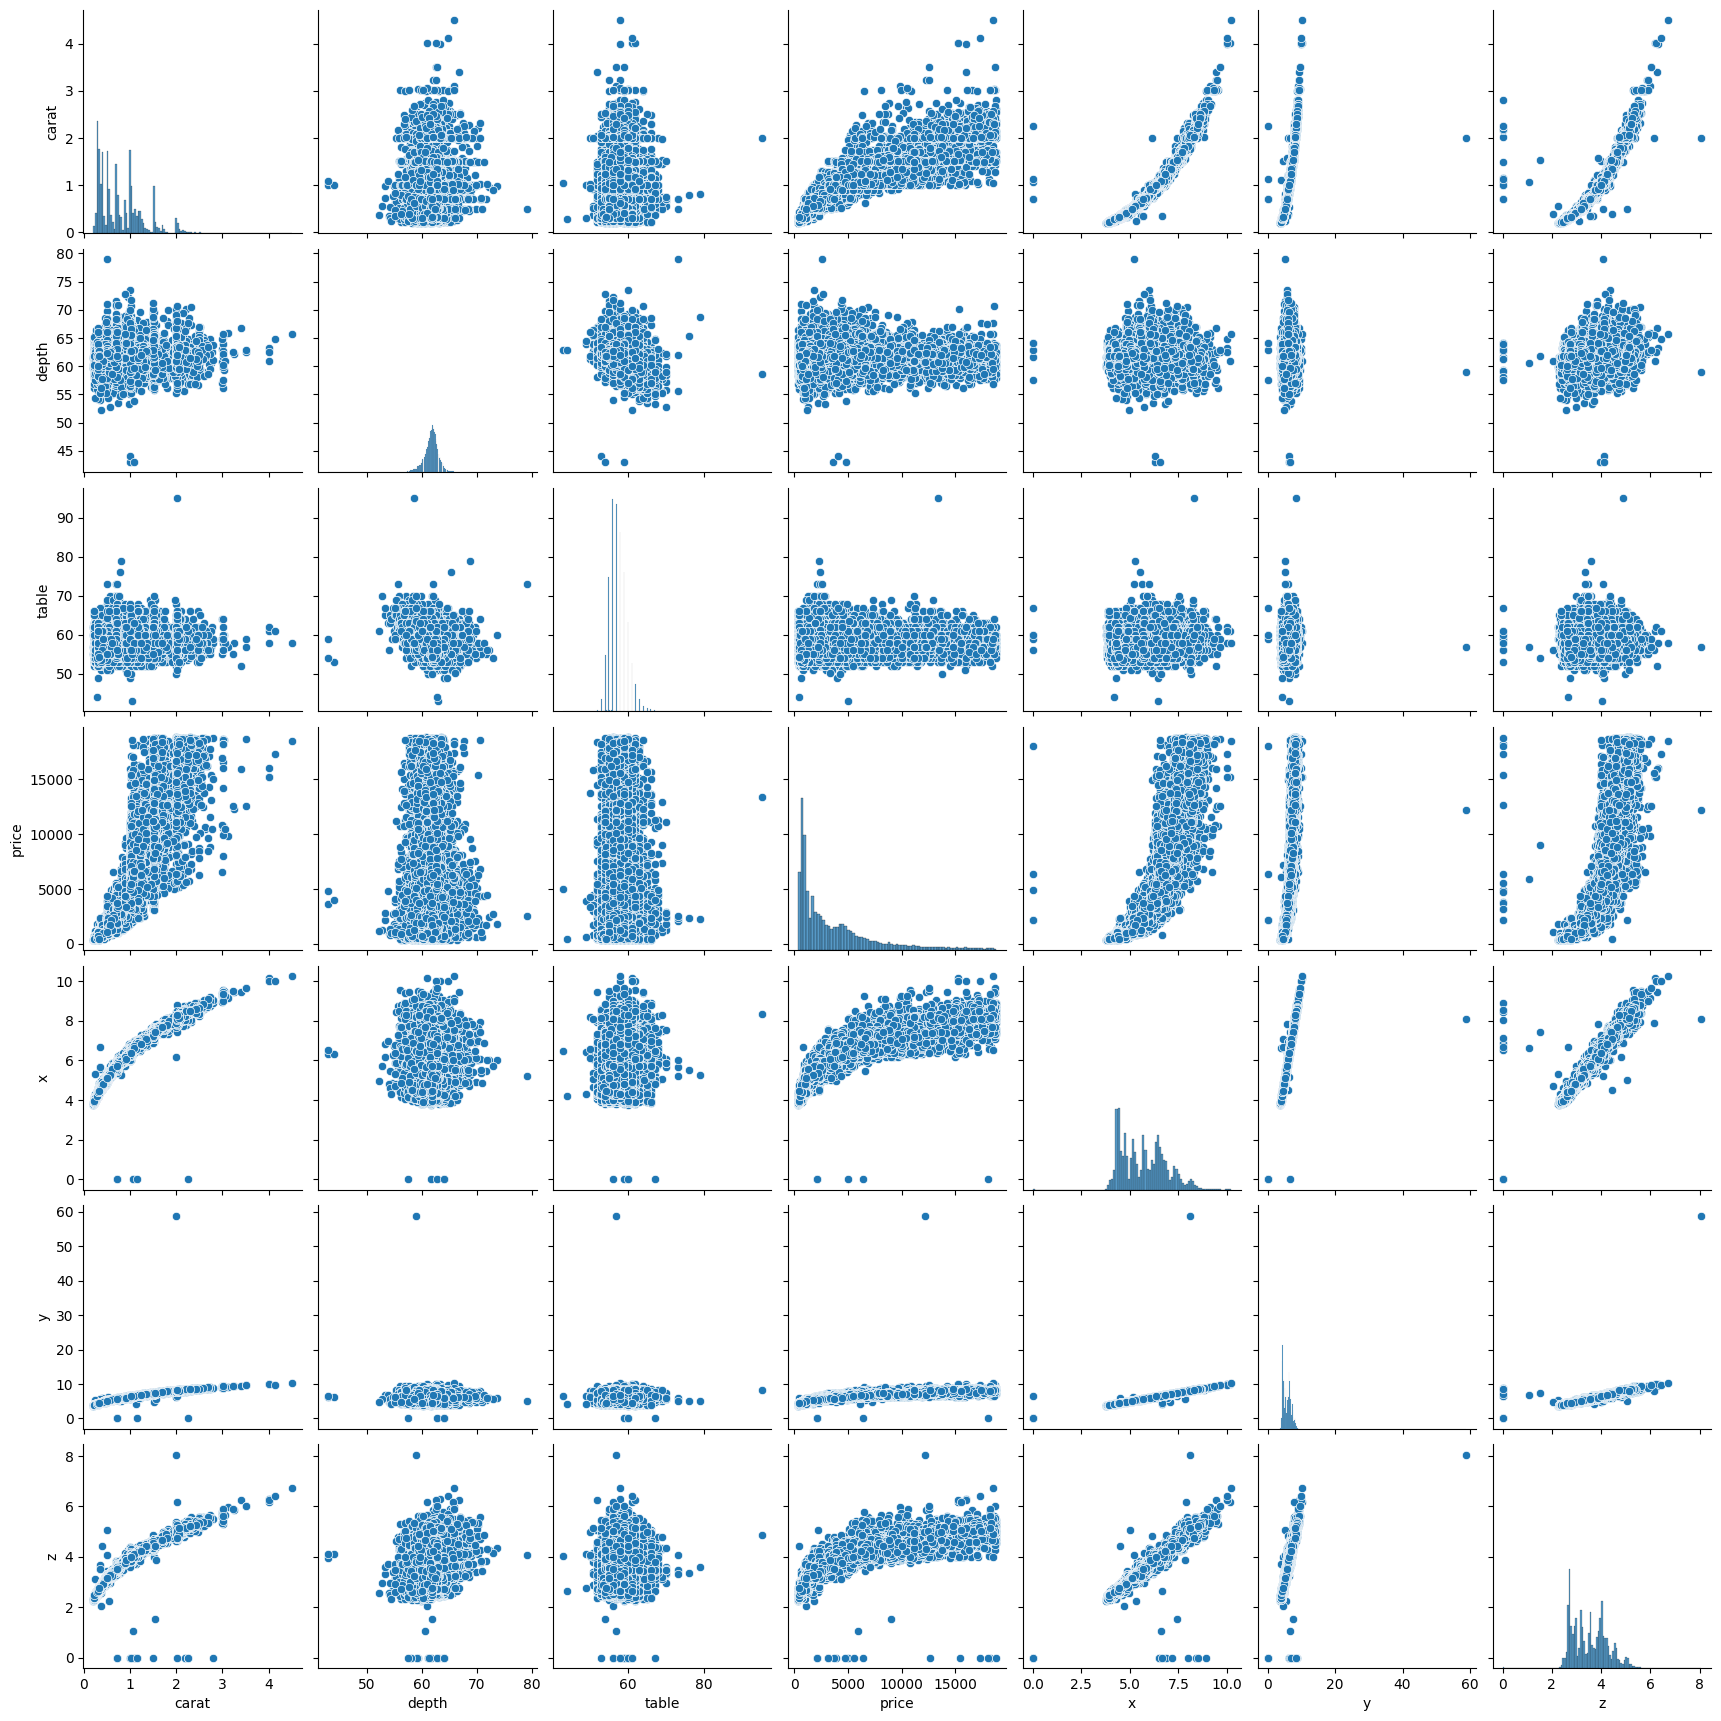

In [13]:
sns.pairplot(train)
plt.savefig("Visualizations/Pairplot.png")

## Feature Engineering

In [14]:
cols = ["cut", "color", "clarity"]
le = {}
encoder = LabelEncoder()

for col in cols:
    encoder = LabelEncoder()
    train[col] = encoder.fit_transform(train[col].astype(str))
    le[col] = encoder


for col in cols:
    encoder = le[col]
    
    mapping = {cls: i for i, cls in enumerate(encoder.classes_)}
    
    test[col] = test[col].astype(str).map(mapping)
    
    # handle unseen categories
    test[col] = test[col].fillna(-1)

In [15]:
test_ids = test["id"]

In [16]:
def diamond_features(df, fit=False, state=None, n_gmm=4):
    if state is None:
        state = {}

    df = df.copy()

    df['volume'] = df['x'] * df['y'] * df['z']

    df['log_carat'] = np.log(df['carat'].clip(lower=1e-6))
    df['log_volume'] = np.log(df['volume'].clip(lower=1e-6))

    df['carat_sq'] = df['carat'] ** 2
    df['carat_cu'] = df['carat'] ** 3

    df['xy_ratio'] = df['x'] / df['y']
    df['xz_ratio'] = df['x'] / df['z']
    df['yz_ratio'] = df['y'] / df['z']

    df['carat_depth'] = df['carat'] * df['depth']
    df['carat_table'] = df['carat'] * df['table']

    
    df = df.sort_values('carat')

    df['carat_diff'] = df['carat'].diff()
    df['local_density'] = 1 / (df['carat_diff'].abs() + 1e-6)

    # Restore original order
    df = df.sort_index()

    df['geom_vol'] = df[['x', 'y', 'z']].std(axis=1)

    # --- Base model ---
    X = df[['log_carat']]

    if fit:
        df['log_price'] = np.log(df['price'].clip(lower=1e-6))
        state['base_model'] = LinearRegression().fit(X, df['log_price'])

    df['base_pred'] = state['base_model'].predict(X)

    has_price = 'price' in df.columns

    if has_price:
        df['log_price'] = np.log(df['price'].clip(lower=1e-6))
        df['residual'] = df['log_price'] - df['base_pred']
    else:
        df['log_price'] = df['base_pred']
        df['residual'] = 0.0

    
    gmm_cols = [
        'log_carat', 'log_volume', 'depth', 'table',
        'carat_sq', 'carat_cu',
        'xy_ratio', 'xz_ratio', 'yz_ratio',
        'carat_depth', 'carat_table',
        'local_density', 'geom_vol'
    ]

    gmm_data = df[gmm_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    if fit:
        state['scaler'] = StandardScaler().fit(gmm_data)
        state['gmm'] = GaussianMixture(n_components=n_gmm, random_state=42)

        scaled = state['scaler'].transform(gmm_data)
        state['gmm'].fit(scaled)
    else:
        scaled = state['scaler'].transform(gmm_data)

    probs = state['gmm'].predict_proba(scaled)
    labels = state['gmm'].predict(scaled)

    df['regime'] = labels

    for i in range(n_gmm):
        df[f'regime_prob_{i}'] = probs[:, i]
        df[f'geom_regime_{i}'] = df['geom_vol'] * df[f'regime_prob_{i}']

    
    feature_cols = (
        ['volume', 'log_carat', 'log_volume',
         'carat_sq', 'carat_cu',
         'xy_ratio', 'xz_ratio', 'yz_ratio',
         'carat_depth', 'carat_table',
         'carat_diff', 'local_density', 'geom_vol',
         'base_pred', 'log_price', 'residual']
        + [f'regime_prob_{i}' for i in range(n_gmm)]
        + [f'geom_regime_{i}' for i in range(n_gmm)]
    )

    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0

    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df, state

In [17]:
# TRAIN
train, state = diamond_features(train, fit=True)

# TEST
test, _ = diamond_features(test, fit=False, state=state)

In [18]:
train

,carat,cut,color,clarity,depth,table,price,x,y,z,...,residual,regime,regime_prob_0,geom_regime_0,regime_prob_1,geom_regime_1,regime_prob_2,geom_regime_2,regime_prob_3,geom_regime_3
0,1.21,3,6,5,62.4,58.0,4268,6.83,6.79,4.25,...,-0.407665,0,1.0,1.478152,3.052075e-13,4.511430e-13,0.000000e+00,0.000000e+00,0.0,0.000000
1,0.32,4,4,5,63.0,57.0,505,4.35,4.38,2.75,...,-0.314717,2,0.0,0.000000,2.877760e-44,2.683630e-44,1.000000e+00,9.325413e-01,0.0,0.000000
2,0.71,0,3,4,65.5,55.0,2686,5.62,5.53,3.65,...,0.021982,0,1.0,1.112310,1.772911e-08,1.972027e-08,1.329661e-64,1.478995e-64,0.0,0.000000
3,0.41,1,0,2,63.8,56.0,738,4.68,4.72,3.00,...,-0.350355,2,0.0,0.000000,1.454409e-30,1.427792e-30,1.000000e+00,9.816992e-01,0.0,0.000000
4,1.02,2,3,2,60.5,59.0,4882,6.55,6.51,3.95,...,0.012794,0,1.0,1.489698,5.470116e-14,8.148820e-14,0.000000e+00,0.000000e+00,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40450,1.34,2,3,4,62.7,57.0,10070,7.10,7.04,4.43,...,0.279861,0,1.0,1.524499,2.907385e-07,4.432308e-07,0.000000e+00,0.000000e+00,0.0,0.000000
40451,2.02,1,2,3,57.1,60.0,12615,8.31,8.25,4.73,...,-0.182110,3,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,2.049813
40452,1.01,2,4,2,62.7,56.0,5457,6.37,6.42,4.01,...,0.140637,0,1.0,1.377207,9.529201e-15,1.312369e-14,0.000000e+00,0.000000e+00,0.0,0.000000
40453,0.33,2,6,4,61.9,54.3,456,4.45,4.47,2.76,...,-0.468313,2,0.0,0.000000,3.574730e-53,3.508764e-53,1.000000e+00,9.815464e-01,0.0,0.000000


In [19]:
test

,id,carat,cut,color,clarity,depth,table,x,y,z,...,residual,regime,regime_prob_0,geom_regime_0,regime_prob_1,geom_regime_1,regime_prob_2,geom_regime_2,regime_prob_3,geom_regime_3
0,0,0.79,4,2,2,62.7,60.0,5.82,5.89,3.67,...,0.0,0,1.000000e+00,1.261996e+00,1.105815e-14,1.395533e-14,1.584579e-191,1.999732e-191,0.0,0.000000
1,1,1.20,2,6,4,61.0,57.0,6.81,6.89,4.18,...,0.0,0,1.000000e+00,1.542044e+00,5.059157e-13,7.801444e-13,0.000000e+00,0.000000e+00,0.0,0.000000
2,2,1.57,3,4,2,62.2,61.0,7.38,7.32,4.57,...,0.0,3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,1.605314
3,3,0.90,4,2,2,63.8,54.0,6.09,6.13,3.90,...,0.0,0,1.000000e+00,1.276101e+00,2.476791e-15,3.160635e-15,0.000000e+00,0.000000e+00,0.0,0.000000
4,4,0.50,4,2,4,62.9,58.0,5.05,5.09,3.19,...,0.0,2,1.498567e-94,1.626849e-94,8.208159e-21,8.910800e-21,1.000000e+00,1.085603e+00,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13480,13480,0.57,2,1,2,61.9,56.0,5.35,5.32,3.30,...,0.0,2,1.241661e-27,1.458957e-27,2.583866e-20,3.036052e-20,1.000000e+00,1.175004e+00,0.0,0.000000
13481,13481,0.71,2,5,5,62.2,55.0,5.71,5.73,3.56,...,0.0,0,1.000000e+00,1.247117e+00,1.025284e-16,1.278649e-16,4.142687e-47,5.166414e-47,0.0,0.000000
13482,13482,0.70,2,2,4,61.6,55.0,5.75,5.71,3.53,...,0.0,0,1.000000e+00,1.270328e+00,3.967548e-16,5.040087e-16,2.482502e-37,3.153592e-37,0.0,0.000000
13483,13483,0.70,4,2,3,58.8,57.0,5.85,5.89,3.45,...,0.0,0,1.000000e+00,1.397331e+00,1.830568e-11,2.557909e-11,4.146942e-47,5.794650e-47,0.0,0.000000


In [20]:
train_cols = list(train.columns) 

for col in list(test.columns):
    if col not in train_cols:
        print(col)

id


## Modelling

In [21]:
rdg = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=5.0, solver="auto", random_state=42))
])

svr = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=10.0, epsilon=0.1, kernel="rbf", gamma="scale"))
])

gbt = Pipeline([
    ("transformer", QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=42)),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

rfr = Pipeline([
    ("transformer", QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=42)),
    ("model", RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

xgbr = Pipeline([
    ("transformer", QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=42)),
    ("model", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

lgbr = Pipeline([
    ("transformer", QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=42)),
    ("model", LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=0,
        n_jobs=-1
    ))
])

cbr = Pipeline([
    ("transformer", QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=42)),
    ("model", CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    ))
])


In [22]:
X = train.drop(columns=["price", "log_price", "residual", "base_pred"], axis=1)
y = train["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
models = {
    "Ridge": rdg,
    "SVR": svr,
    "GradientBoosting": gbt,
    "RandomForest": rfr,
    "XGBoost": xgbr,
    "LightGBM": lgbr,
    "CatBoost": cbr
}

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


mlflow.set_experiment("diamond_models")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    rmses, maes, r2s = [], [], []

    with mlflow.start_run(run_name=name):

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            rmse, mae, r2 = evaluate(y_val, preds)

            rmses.append(rmse)
            maes.append(mae)
            r2s.append(r2)

            print(f"{name} | Fold {fold+1} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

        mlflow.log_param("model", name)
        mlflow.log_param("n_splits", 5)

        mlflow.log_metric("rmse_mean", np.mean(rmses))
        mlflow.log_metric("mae_mean", np.mean(maes))
        mlflow.log_metric("r2_mean", np.mean(r2s))

        mlflow.log_metric("rmse_std", np.std(rmses))
        mlflow.log_metric("mae_std", np.std(maes))
        mlflow.log_metric("r2_std", np.std(r2s))

        print(f"\n{name} SUMMARY")
        print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
        print(f"MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
        print(f"R2  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}\n")

Ridge | Fold 1 | RMSE: 1303.8808 | MAE: 823.5993 | R2: 0.8943
Ridge | Fold 2 | RMSE: 2414.5247 | MAE: 826.0105 | R2: 0.6186
Ridge | Fold 3 | RMSE: 1281.5036 | MAE: 809.6069 | R2: 0.8955
Ridge | Fold 4 | RMSE: 1308.4515 | MAE: 819.7681 | R2: 0.8977
Ridge | Fold 5 | RMSE: 1228.7795 | MAE: 795.7213 | R2: 0.9022

Ridge SUMMARY
RMSE: 1507.4280 ± 454.4303
MAE : 814.9412 ± 11.1234
R2  : 0.8417 ± 0.1115

SVR | Fold 1 | RMSE: 2879.0801 | MAE: 2050.4700 | R2: 0.4845
SVR | Fold 2 | RMSE: 2825.0327 | MAE: 2024.3245 | R2: 0.4779
SVR | Fold 3 | RMSE: 2741.4354 | MAE: 1983.5921 | R2: 0.5218
SVR | Fold 4 | RMSE: 2905.0440 | MAE: 2048.6365 | R2: 0.4956
SVR | Fold 5 | RMSE: 2811.6803 | MAE: 2006.2393 | R2: 0.4878

SVR SUMMARY
RMSE: 2832.4545 ± 56.9461
MAE : 2022.6525 ± 25.4829
R2  : 0.4935 ± 0.0152

GradientBoosting | Fold 1 | RMSE: 644.9225 | MAE: 349.7726 | R2: 0.9741
GradientBoosting | Fold 2 | RMSE: 626.4016 | MAE: 340.4500 | R2: 0.9743
GradientBoosting | Fold 3 | RMSE: 622.6384 | MAE: 342.0093 | R2

In [24]:
"price" in X_train.columns

False

In [25]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,32364.0,0.798246,0.474805,0.200000,4.000000e-01,7.000000e-01,1.040000e+00,4.500000
cut,32364.0,2.549870,1.027035,0.000000,2.000000e+00,2.000000e+00,3.000000e+00,4.000000
color,32364.0,2.602212,1.702723,0.000000,1.000000e+00,3.000000e+00,4.000000e+00,6.000000
clarity,32364.0,3.838339,1.720409,0.000000,2.000000e+00,4.000000e+00,5.000000e+00,7.000000
depth,32364.0,61.751567,1.435210,43.000000,6.100000e+01,6.180000e+01,6.250000e+01,79.000000
table,32364.0,57.444114,2.223058,43.000000,5.600000e+01,5.700000e+01,5.900000e+01,79.000000
x,32364.0,5.731290,1.123242,0.000000,4.710000e+00,5.700000e+00,6.540000e+00,10.230000
y,32364.0,5.734817,1.152972,0.000000,4.720000e+00,5.710000e+00,6.540000e+00,58.900000
z,32364.0,3.538226,0.696570,0.000000,2.910000e+00,3.530000e+00,4.030000e+00,8.060000
volume,32364.0,129.900760,79.321326,0.000000,6.491335e+01,1.148891e+02,1.708567e+02,3840.598060


In [ ]:
voting = VotingRegressor( estimators=[("rdg", rdg), ("gbt", gbt), ("rfr", rfr), ("cbr", cbr)], weights=[0.90, 0.97, 0.96, 0.98], n_jobs=-1 )

mlflow.set_experiment("diamond_models_ensemble")

rmses, maes, r2s = [], [], []

with mlflow.start_run(run_name=name):

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    voting.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    rmse, mae, r2 = evaluate(y_val, preds)

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print(f"{name} | Fold {fold+1} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    mlflow.log_param("model", name)
    mlflow.log_param("n_splits", 5)

    mlflow.log_metric("rmse_mean", np.mean(rmses))
    mlflow.log_metric("mae_mean", np.mean(maes))
    mlflow.log_metric("r2_mean", np.mean(r2s))

    mlflow.log_metric("rmse_std", np.std(rmses))
    mlflow.log_metric("mae_std", np.std(maes))
    mlflow.log_metric("r2_std", np.std(r2s))

    print(f"\n{name} SUMMARY")
    print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"R2  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}\n")

## Test Set Prediction

In [27]:
test = test.drop(columns=["id", "log_price", "residual", "base_pred"], axis=1)
test_ids = test_ids.loc[test.index]

submission = pd.DataFrame({
    "id": test_ids,
    "price": cbr.predict(test) 
})

submission.to_csv("submission.csv", index=False)

In [28]:
test

,carat,cut,color,clarity,depth,table,x,y,z,volume,...,geom_vol,regime,regime_prob_0,geom_regime_0,regime_prob_1,geom_regime_1,regime_prob_2,geom_regime_2,regime_prob_3,geom_regime_3
0,0.79,4,2,2,62.7,60.0,5.82,5.89,3.67,125.806866,...,1.261996,0,1.000000e+00,1.261996e+00,1.105815e-14,1.395533e-14,1.584579e-191,1.999732e-191,0.0,0.000000
1,1.20,2,6,4,61.0,57.0,6.81,6.89,4.18,196.129362,...,1.542044,0,1.000000e+00,1.542044e+00,5.059157e-13,7.801444e-13,0.000000e+00,0.000000e+00,0.0,0.000000
2,1.57,3,4,2,62.2,61.0,7.38,7.32,4.57,246.878712,...,1.605314,3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,1.605314
3,0.90,4,2,2,63.8,54.0,6.09,6.13,3.90,145.593630,...,1.276101,0,1.000000e+00,1.276101e+00,2.476791e-15,3.160635e-15,0.000000e+00,0.000000e+00,0.0,0.000000
4,0.50,4,2,4,62.9,58.0,5.05,5.09,3.19,81.997355,...,1.085603,2,1.498567e-94,1.626849e-94,8.208159e-21,8.910800e-21,1.000000e+00,1.085603e+00,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13480,0.57,2,1,2,61.9,56.0,5.35,5.32,3.30,93.924600,...,1.175004,2,1.241661e-27,1.458957e-27,2.583866e-20,3.036052e-20,1.000000e+00,1.175004e+00,0.0,0.000000
13481,0.71,2,5,5,62.2,55.0,5.71,5.73,3.56,116.477148,...,1.247117,0,1.000000e+00,1.247117e+00,1.025284e-16,1.278649e-16,4.142687e-47,5.166414e-47,0.0,0.000000
13482,0.70,2,2,4,61.6,55.0,5.75,5.71,3.53,115.898725,...,1.270328,0,1.000000e+00,1.270328e+00,3.967548e-16,5.040087e-16,2.482502e-37,3.153592e-37,0.0,0.000000
13483,0.70,4,2,3,58.8,57.0,5.85,5.89,3.45,118.874925,...,1.397331,0,1.000000e+00,1.397331e+00,1.830568e-11,2.557909e-11,4.146942e-47,5.794650e-47,0.0,0.000000
